In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from tabulate import tabulate
import emoji
from PIL import Image
import io


In [2]:
# Load the emoji dataset
def load_dataset(file_path):
    # Load the dataset and return as a pandas dataframe
    df = pd.read_csv(file_path)
    return df

# Get the most popular emojis
def get_most_popular_emojis(df, top_n=10):
    # Count occurrences of each emoji
    emoji_counts = df['Emoji'].value_counts().reset_index()
    emoji_counts.columns = ['Emoji', 'Count']
    
    # Merge with the original dataframe to maintain context and other details
    popular_emojis = pd.merge(emoji_counts, df, on='Emoji').drop_duplicates('Emoji').sort_values(by='Count', ascending=False).head(top_n)
    return popular_emojis

# Display the context of the most popular emojis
def display_emoji_context(df):
    print("Most Popular Emojis and Their Contexts:\n")
    for index, row in df.iterrows():
        emoji = row['Emoji']
        count = row['Count']
        context = row['Context']
        platform = row['Platform']
        user_age = row['User Age']
        user_gender = row['User Gender']
        print(f"Emoji: {emoji} | Count: {count} | Context: {context} | Platform: {platform} | Age: {user_age} | Gender: {user_gender}\n")

# Main code execution
file_path = 'emoji_usage_dataset.csv'  # Define the file path first
df = load_dataset(file_path)  # Load the dataset

# Get the top N most popular emojis (which includes the 'Count' column)
popular_emojis = get_most_popular_emojis(df, top_n=10)

# Call the function to display the context
display_emoji_context(popular_emojis)

Most Popular Emojis and Their Contexts:

Emoji: 🤣 | Count: 193 | Context: celebration | Platform: Snapchat | Age: 56 | Gender: Female

Emoji: 👏 | Count: 185 | Context: love | Platform: Twitter | Age: 16 | Gender: Male

Emoji: 😭 | Count: 184 | Context: support | Platform: Facebook | Age: 29 | Gender: Male

Emoji: 🙏 | Count: 184 | Context: surprise | Platform: WhatsApp | Age: 33 | Gender: Female

Emoji: 💕 | Count: 182 | Context: happy | Platform: WhatsApp | Age: 17 | Gender: Female

Emoji: 💔 | Count: 181 | Context: confusion | Platform: Snapchat | Age: 45 | Gender: Female

Emoji: 🤪 | Count: 178 | Context: celebration | Platform: Twitter | Age: 37 | Gender: Male

Emoji: 🎉 | Count: 177 | Context: sad | Platform: Facebook | Age: 37 | Gender: Female

Emoji: 😜 | Count: 176 | Context: surprise | Platform: TikTok | Age: 62 | Gender: Female

Emoji: 🤔 | Count: 176 | Context: confusion | Platform: Facebook | Age: 42 | Gender: Male




Most Popular Emojis:
 +-------+-------+-------------+
| Emoji | Count |   Context   |
+-------+-------+-------------+
|  🤣   |  193  | celebration |
|  👏   |  185  |    love     |
|  😭   |  184  |   support   |
|  🙏   |  184  |  surprise   |
|  💕   |  182  |    happy    |
|  💔   |  181  |  confusion  |
|  🤪   |  178  | celebration |
|  🎉   |  177  |     sad     |
|  😜   |  176  |  surprise   |
|  🤔   |  176  |  confusion  |
+-------+-------+-------------+


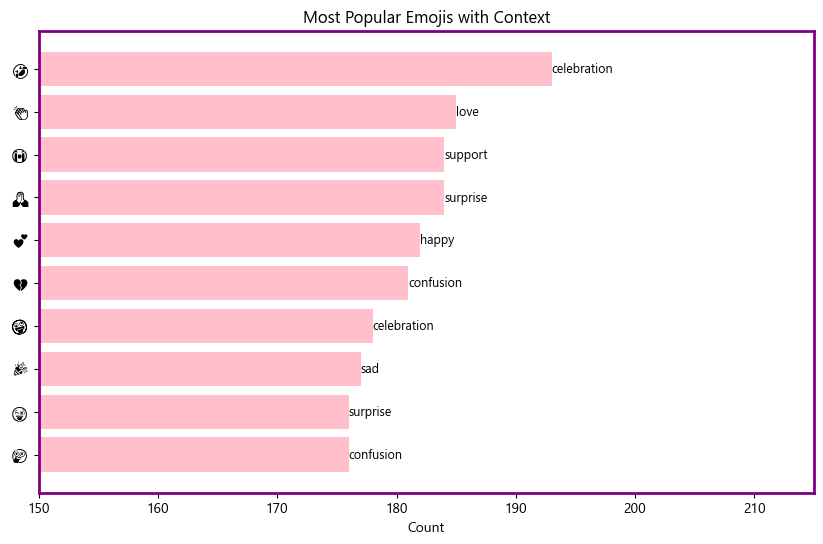

In [21]:
# Set the font family to Segoe UI Emoji
plt.rcParams['font.family'] = 'Segoe UI Emoji'

# Function to convert emoji text to its visual representation (string format)
def emoji_to_image(emoji_text):
    return emoji.emojize(emoji_text)  # Use emoji library to get a visual representation

# Get the most popular emojis
def get_most_popular_emojis(df, top_n=10):
    emoji_counts = df['Emoji'].value_counts().reset_index()
    emoji_counts.columns = ['Emoji', 'Count']
    
    popular_emojis = pd.merge(emoji_counts, df, on='Emoji').drop_duplicates('Emoji').sort_values(by='Count', ascending=False).head(top_n)
    return popular_emojis

# Function to display emojis in a formatted table
def display_emojis(popular_emojis):
    print("\nMost Popular Emojis:\n", tabulate(popular_emojis[['Emoji', 'Count', 'Context']], headers='keys', tablefmt='pretty', showindex=False))

# Function to plot popular emojis with context
def plot_popular_emojis_with_context(popular_emojis):
    plt.figure(figsize=(10, 6))
    bars = plt.barh(popular_emojis['Emoji'].apply(emoji_to_image), popular_emojis['Count'], color='pink')  # Use emoji images
    plt.xlabel('Count')
    plt.title('Most Popular Emojis with Context')
    plt.gca().invert_yaxis()  # Invert y-axis to have the highest count on top

    # Set the x-axis limits
    plt.xlim(150, 215)  # Focus on the range between 150 and 225

    # Annotate each bar with the context
    for bar, context in zip(bars, popular_emojis['Context']):
        plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, context, 
                 va='center', ha='left', fontsize=9)

    # Add a bright purple border to the plot
    ax = plt.gca()
    ax.spines['top'].set_color('purple')
    ax.spines['top'].set_linewidth(2)
    ax.spines['right'].set_color('purple')
    ax.spines['right'].set_linewidth(2)
    ax.spines['left'].set_color('purple')
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_color('purple')
    ax.spines['bottom'].set_linewidth(2)

    plt.show()



# Function to display the most popular emojis
def display_popular_emojis(file_path, top_n=10):
    # Load the dataset once
    df = load_dataset(file_path)
    
    # Get the top N most popular emojis
    popular_emojis = get_most_popular_emojis(df, top_n)
    
    # Display the result using the display function
    display_emojis(popular_emojis)
    
    # Plot the popular emojis with context
    plot_popular_emojis_with_context(popular_emojis)

# Example usage
file_path = 'emoji_usage_dataset.csv'  # Update this to your actual file path
display_popular_emojis(file_path, top_n=10)

In [4]:
# Analyze usage of emojis across different platforms, age groups, and genders
def analyze_emoji_by_demographics(df):
    print("\nEmoji Usage by Demographics:\n")
    
    # Group by emoji and platform and count occurrences
    platform_usage = df.groupby(['Emoji', 'Platform']).size().reset_index(name='Count')
    
    # Sum counts for each platform to get total usage per platform
    total_platform_usage = platform_usage.groupby('Platform')['Count'].sum().reset_index()
    
    # Sort by Count in descending order to find the most popular platform
    total_platform_usage = total_platform_usage.sort_values(by='Count', ascending=False)

    print("Total Emoji Usage by Platform:\n", tabulate(total_platform_usage, headers='keys', tablefmt='pretty', showindex=False))


# Example usage:
df = load_dataset(file_path)  # Assuming you have the dataset loaded
analyze_emoji_by_demographics(df)



Emoji Usage by Demographics:

Total Emoji Usage by Platform:
 +-----------+-------+
| Platform  | Count |
+-----------+-------+
|  Twitter  |  854  |
| WhatsApp  |  838  |
| Facebook  |  830  |
|  TikTok   |  830  |
| Snapchat  |  829  |
| Instagram |  819  |
+-----------+-------+


In [5]:
# Function to categorize ages into defined ranges
def categorize_age(age):
    if age < 13:
        return "Preteen (0-12)"
    elif 13 <= age < 20:
        return "Teen (13-19)"
    elif 20 <= age < 35:
        return "Young Adult (20-34)"
    elif 35 <= age < 50:
        return "Adult (35-49)"
    else:
        return "Senior (50+)"

# Analyze total emoji usage by categorized age groups and genders
def analyze_emoji_by_demographics(df):
    
    # Apply age categorization
    df['Age Group'] = df['User Age'].apply(categorize_age)

    # Group by age group and count the total number of emojis used by each age group
    age_usage = df.groupby('Age Group').size().reset_index(name='Total Emojis')
    
    # Sort by 'Total Emojis' in descending order
    age_usage = age_usage.sort_values(by='Total Emojis', ascending=False)

    # Print the result using tabulate for better formatting
    print("Total Emojis Used by Age Group:\n", tabulate(age_usage, headers='keys', tablefmt='pretty', showindex=False))

# Example usage:
file_path = 'emoji_usage_dataset.csv'  # Update this to your actual file path
df = load_dataset(file_path)  # Assuming you have the dataset loaded
analyze_emoji_by_demographics(df)


Total Emojis Used by Age Group:
 +---------------------+--------------+
|      Age Group      | Total Emojis |
+---------------------+--------------+
|    Senior (50+)     |     1515     |
| Young Adult (20-34) |     1433     |
|    Adult (35-49)    |     1396     |
|    Teen (13-19)     |     656      |
+---------------------+--------------+


In [6]:
# Function to analyze total emoji usage by gender
def analyze_emoji_by_demographics(df):
    # Group by gender and count the total number of emojis used by each gender
    gender_usage = df.groupby('User Gender').size().reset_index(name='Total Emojis')
    
    # Sort by 'Total Emojis' in descending order
    gender_usage = gender_usage.sort_values(by='Total Emojis', ascending=False)

    # Print the result using tabulate for better formatting
    print("\nTotal Emojis Used by Gender:\n", tabulate(gender_usage, headers='keys', tablefmt='pretty', showindex=False))

# Example usage:
file_path = 'emoji_usage_dataset.csv'  # Update this to your actual file path
df = load_dataset(file_path)  # Assuming you have the dataset loaded
analyze_emoji_by_demographics(df)



Total Emojis Used by Gender:
 +-------------+--------------+
| User Gender | Total Emojis |
+-------------+--------------+
|    Male     |     2537     |
|   Female    |     2463     |
+-------------+--------------+
